In [1]:
!pip install tensorflow pandas numpy scikit-learn ytmusicapi datasets

In [2]:
import datasets
import huggingface_hub

print(datasets.__version__)
print(huggingface_hub.__version__)


4.8.5
1.17.0


# Loading the dataset frome HuggingFace

In [3]:
from datasets import load_dataset

dataset = load_dataset("dair-ai/emotion")

print(dataset["train"][0])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:122: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


{'text': 'i didnt feel humiliated', 'label': 0}


In [4]:
print(dataset["validation"][0])

{'text': 'im feeling quite sad and sorry for myself but ill snap out of it soon', 'label': 0}


In [5]:
print(dataset["test"][0])

{'text': 'im feeling rather rotten so im not very ambitious right now', 'label': 0}


In [6]:
train_df = dataset["train"].to_pandas()
val_df = dataset["validation"].to_pandas()
test_df = dataset["test"].to_pandas()

train_df.head()

,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3


In [7]:
label_names = dataset["train"].features["label"].names

train_df["emotion"] = train_df["label"].apply(
    lambda x: label_names[x]
)

train_df.head()

,text,label,emotion
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger


In [8]:
train_df["emotion"].value_counts()

,count
emotion,
joy,5362
sadness,4666
anger,2159
fear,1937
love,1304
surprise,572


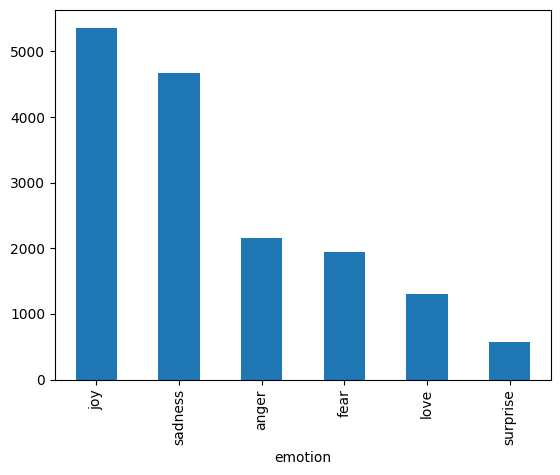

In [9]:
import matplotlib.pyplot as plt

train_df["emotion"].value_counts().plot(kind="bar")
plt.show()

In [10]:
print(train_df["label"].value_counts(normalize=True))

label
1    0.335125
0    0.291625
3    0.134937
4    0.121063
2    0.081500
5    0.035750
Name: proportion, dtype: float64


# Tokenization

In [11]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer(num_words=10000)

tokenizer.fit_on_texts(train_df["text"])

In [12]:
len(tokenizer.word_index)

15212

# Convert text to numbers

In [13]:
sample_text = train_df["text"][0]

print(sample_text)

i didnt feel humiliated


In [14]:
sequence = tokenizer.texts_to_sequences([sample_text])

print(sequence)

[[1, 138, 2, 678]]


# Padding

In [15]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_LEN = 50

X_train = pad_sequences(
    tokenizer.texts_to_sequences(train_df["text"]),
    maxlen=MAX_LEN,
    padding="post"
)

In [16]:
X_train.shape

(16000, 50)

# Labels

In [17]:
y_train = train_df["label"]

In [18]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = dict(
    zip(classes, weights)
)

print(class_weights)

{np.int64(0): np.float64(0.5715102157451064), np.int64(1): np.float64(0.49732686808404825), np.int64(2): np.float64(2.044989775051125), np.int64(3): np.float64(1.2351397251814111), np.int64(4): np.float64(1.3766993632765445), np.int64(5): np.float64(4.662004662004662)}


In [19]:
y_train[:10]

,label
0,0
1,0
2,3
3,2
4,3
5,0
6,5
7,4
8,1
9,2


# Validation data

In [20]:
X_val = pad_sequences(
    tokenizer.texts_to_sequences(val_df["text"]),
    maxlen=MAX_LEN,
    padding="post"
)

y_val = val_df["label"]

# LSTM Model

In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, LSTM, Dense, Dropout, Input, Embedding
from tensorflow.keras.callbacks import EarlyStopping


# 1. Build Model
model = Sequential([
    Input(shape=(MAX_LEN,)),

    Embedding(
        input_dim=10000,
        output_dim=128
    ),

    Bidirectional(
        LSTM(128)
    ),

    Dropout(0.5),

    Dense(64, activation="relu"),

    Dense(6, activation="softmax")
])

# 2. Compile Model
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# 3. Define Early Stopping
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

# 4. Train Model
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=6,
    batch_size=64,
    class_weight=class_weights,
    callbacks=[early_stop]
)

Epoch 1/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 130s 488ms/step - accuracy: 0.3199 - loss: 1.5121 - val_accuracy: 0.6605 - val_loss: 0.7876
Epoch 2/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 117s 469ms/step - accuracy: 0.8146 - loss: 0.4685 - val_accuracy: 0.8745 - val_loss: 0.4159
Epoch 3/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 110s 441ms/step - accuracy: 0.9106 - loss: 0.2374 - val_accuracy: 0.8890 - val_loss: 0.3687
Epoch 4/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 93s 244ms/step - accuracy: 0.9457 - loss: 0.1504 - val_accuracy: 0.8935 - val_loss: 0.3528
Epoch 5/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 135s 459ms/step - accuracy: 0.9603 - loss: 0.1044 - val_accuracy: 0.8895 - val_loss: 0.3625
Epoch 6/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 145s 468ms/step - accuracy: 0.9679 - loss: 0.0838 - val_accuracy: 0.8950 - val_loss: 0.4236


# Model Summary

In [22]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 50, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 256)            │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,680,020 (17.85 MB)

 Trainable params: 1,560,006 (5.95 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,120,014 (11.90 MB)

In [23]:
history.history

{'accuracy': [0.31993749737739563,
  0.8145624995231628,
  0.9106249809265137,
  0.945687472820282,
  0.9603124856948853,
  0.9679375290870667],
 'loss': [1.5120958089828491,
  0.46845361590385437,
  0.23740722239017487,
  0.15042810142040253,
  0.10439079254865646,
  0.0837603434920311],
 'val_accuracy': [0.6604999899864197,
  0.8744999766349792,
  0.8889999985694885,
  0.8934999704360962,
  0.8895000219345093,
  0.8949999809265137],
 'val_loss': [0.7876260876655579,
  0.41589584946632385,
  0.3687470555305481,
  0.3528306484222412,
  0.3624895513057709,
  0.4236040413379669]}

In [24]:
print(history.history["accuracy"])
print(history.history["val_accuracy"])

[0.31993749737739563, 0.8145624995231628, 0.9106249809265137, 0.945687472820282, 0.9603124856948853, 0.9679375290870667]
[0.6604999899864197, 0.8744999766349792, 0.8889999985694885, 0.8934999704360962, 0.8895000219345093, 0.8949999809265137]


In [25]:
preds = model.predict(X_val)

pred_classes = np.argmax(preds, axis=1)

print(np.unique(pred_classes, return_counts=True))

63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 122ms/step
(array([0, 1, 2, 3, 4, 5]), array([542, 688, 180, 287, 204,  99]))


# Training

In [26]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=64
)

Epoch 1/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 83s 315ms/step - accuracy: 0.9596 - loss: 0.1223 - val_accuracy: 0.9030 - val_loss: 0.2958
Epoch 2/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 121s 484ms/step - accuracy: 0.9711 - loss: 0.0868 - val_accuracy: 0.9045 - val_loss: 0.3657
Epoch 3/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 98s 391ms/step - accuracy: 0.9783 - loss: 0.0637 - val_accuracy: 0.9005 - val_loss: 0.3775
Epoch 4/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 129s 338ms/step - accuracy: 0.9812 - loss: 0.0559 - val_accuracy: 0.8985 - val_loss: 0.3920
Epoch 5/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 82s 330ms/step - accuracy: 0.9829 - loss: 0.0505 - val_accuracy: 0.9005 - val_loss: 0.3833
Epoch 6/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 90s 358ms/step - accuracy: 0.9852 - loss: 0.0439 - val_accuracy: 0.8940 - val_loss: 0.4270
Epoch 7/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 55s 221ms/step - accuracy: 0.9853 - loss: 0.0434 - val_accuracy: 0.9055 - val_loss: 0.4334
Epoch 8/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 55s 221ms/step - accuracy: 0.9858 - loss:

# Plotting accuracy

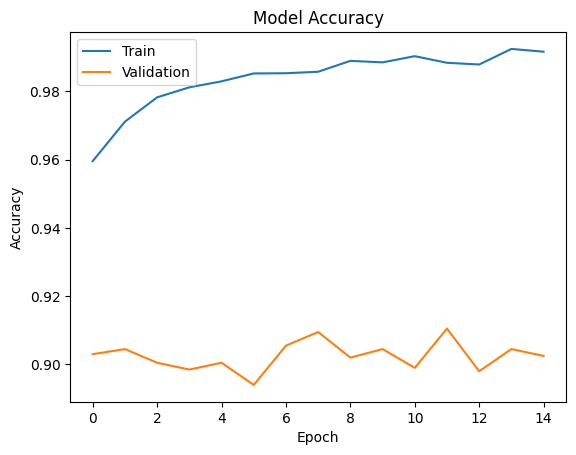

In [27]:
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")

plt.legend(["Train", "Validation"])

plt.show()

In [28]:
label_names = dataset["train"].features["label"].names

import numpy as np

def predict_emotion(text):

    seq = tokenizer.texts_to_sequences([text])

    padded = pad_sequences(
        seq,
        maxlen=MAX_LEN,
        padding="post"
    )

    pred = model.predict(padded, verbose=0)

    emotion_id = np.argmax(pred)

    emotion = label_names[emotion_id]

    confidence = pred[0][emotion_id]

    return emotion, confidence

In [29]:
emotion, confidence = predict_emotion(
    "I am really nervous about my exam tomorrow"
)

print(emotion)
print(confidence)

fear
0.99842584


# Youtube

In [72]:
song_db = {
    "joy": [
        "Last Friday Night Katy Perry",
        "Can't Stop The Feeling Justin Timberlake",
        "Happy Pharrell Williams",
        "Blinding Lights The Weeknd",
        "Born Again"
    ],

    "sadness": [
        "Someone Like You Adele",
        "Fix You Coldplay",
        "All Too Well Taylor Swift",
        "The Night we met"
    ],

    "fear": [
        "Believer Imagine Dragons",
        "Hall Of Fame The Script",
        "Unstoppable Sia",
        "Pray For Me The Weeknd"

    ],

    "anger": [
        "Stronger Kanye West",
        "Remember The Name Fort Minor",
        "Till I Collapse Eminem",
        "Warriors Imagine Dragons"
    ],

    "love": [
        "Perfect Ed Sheeran",
        "Love Story Taylor Swift",
        "Photograph Ed Sheeran",
        "A Thousand Years Christina Perri",
        "Moth to a flame",
        "Take me to Church"
    ],

    "surprise": [
        "Counting Stars OneRepublic",
        "Viva La Vida Coldplay",
        "Firework Katy Perry",
        "Adventure Of A Lifetime Coldplay"
    ]
}

In [42]:
import random

def recommend_song(emotion):

    choice = song_db[emotion].pop()
    #return random.choice(
    #    song_db[emotion]
    return choice

In [32]:
from ytmusicapi import YTMusic

yt = YTMusic()

In [47]:
def get_song_link(song_name):

    results = yt.search(
        song_name,
        filter="songs"
    )

    if len(results) == 0:
        return None

    video_id = results[0]["videoId"]

    return (
        f"https://www.youtube.com/watch?v="
        f"{video_id}"
    )

In [48]:
import random

def ai_dj():

    print("="*50)
    print("🎧 AI MOOD DJ")
    print("="*50)

    user_text = input(
        "\nHow are you feeling today?\n\n> "
    )

    emotion, confidence = predict_emotion(
        user_text
    )

    song = recommend_song(emotion)

    url = get_song_link(song)

    print("\n" + "="*50)

    print(
        f"Detected Emotion: {emotion}"
    )

    print(
        f"Confidence: {confidence:.2%}"
    )

    print(
        f"\n🎵 Recommended Song:"
    )

    print(song)

    print(
        f"\n🔗 Listen Here:\n{url}"
    )

    print("\n" + "="*50)

In [ ]:
ai_dj()

🎧 AI MOOD DJ

Detected Emotion: fear
Confidence: 71.88%

🎵 Recommended Song:
Pray For Me The Weeknd

🔗 Listen Here:
https://www.youtube.com/watch?v=T0pYq_Saf7g

